<div style="border:solid green 2px; padding: 20px"> <h1 style="color:green; margin-bottom:20px">Reviewers comment v1</h1>

Hello!

I'm happy to review your project today 🙌

My name is **Justino Imbert** ([this](https://hub.tripleten.com/u/125e88ae) is my Hub profile) and today I'll be reviewing your project!


You can find my comments under the heading **«Review»**. I will categorize my comments in green, blue or red boxes like this:

<div class="alert alert-success">
    <b>Success:</b> if everything is done successfully
</div>
<div class="alert alert-warning">
    <b>Remarks:</b> if I can give some recommendations or ways to improve the project
</div>
<div class="alert alert-danger">
    <b>Needs fixing:</b> if the block requires some corrections. Work cant be accepted with the red comments
</div>

Please dont remove my comments :) If you have any questions dont hesitate to respond to my comments in a different section. 
<div class="alert alert-info"> <b>Student comments:</b> For example like this</div>   



<div class="alert alert-block alert-info">
<b>Reviewer's comment v1:</b> </a>


You are doing a great job in this project! I left you some comments for you to address before I can approve it!

Looking forward to reviewing your next submission! Best of luck!
    
</div>

<div class="alert alert-block alert-info">
<b>Reviewer's comment v2:</b> </a>

Amazing job with this submission! I'm approving this project!

Best of luck in the next sprints!
    
</div>

In [1]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
from scipy import stats
import seaborn as sns
from IPython.display import display
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix

In [2]:
data = pd.read_csv('/datasets/users_behavior.csv')

In [3]:
display(data.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3214 entries, 0 to 3213
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   calls     3214 non-null   float64
 1   minutes   3214 non-null   float64
 2   messages  3214 non-null   float64
 3   mb_used   3214 non-null   float64
 4   is_ultra  3214 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 125.7 KB


None

In [4]:
display(data.describe())

,calls,minutes,messages,mb_used,is_ultra
count,3214.000000,3214.000000,3214.000000,3214.000000,3214.000000
mean,63.038892,438.208787,38.281269,17207.673836,0.306472
std,33.236368,234.569872,36.148326,7570.968246,0.461100
min,0.000000,0.000000,0.000000,0.000000,0.000000
25%,40.000000,274.575000,9.000000,12491.902500,0.000000
50%,62.000000,430.600000,30.000000,16943.235000,0.000000
75%,82.000000,571.927500,57.000000,21424.700000,1.000000
max,244.000000,1632.060000,224.000000,49745.730000,1.000000


In [5]:
data.shape

(3214, 5)

After reviewing the dataset, I confirmed that there are no missing values or incorrect data types, and the dataset is clean and ready for further analysis.

In [6]:
X = data.drop('is_ultra', axis=1)
y = data['is_ultra']

<div class="alert alert-block alert-success">
<b>Reviewer's comment v1:</b> </a>

Awesome job loading and inspecting the data!
    
</div>

The dataset was split into three parts: 60% for training, 20% for validation, and 20% for testing.
The training set is used to teach the model and adjust its internal parameters.
The validation set helps tune hyperparameters and compare different models without touching the final test data.
Finally, the test set is used to evaluate the model’s performance on unseen data and estimate how well it will generalize to new users.

The 60/20/20 split provides a good balance between having enough data to train the model effectively and keeping enough samples aside for reliable validation and testing.

In [7]:
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.4, random_state=12345)
X_valid, X_test, y_valid, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=12345)

<div class="alert alert-block alert-success">
<b>Reviewer's comment v1:</b> </a>

Good job splitting the data!
    
</div>

I decided to start with the Decision Tree Classifier because it is easy to interpret and allows manual tuning of hyperparameters to better understand how the model behaves.

In [8]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

In [9]:
# basic model
model_tree = DecisionTreeClassifier(random_state=12345)
model_tree.fit(X_train, y_train)

pred_valid = model_tree.predict(X_valid)
accuracy_valid = accuracy_score(y_valid, pred_valid)

print("Accuracy (basic model):", accuracy_valid)

Accuracy (basic model): 0.713841368584759


The basic Decision Tree model achieved an accuracy of 0.714 on the validation dataset.
Although this result shows that the model is learning useful patterns from the data, it does not reach the required project threshold of 0.75.

To improve the model’s performance, I will manually tune its hyperparameters.
The first parameter to adjust is the maximum depth (max_depth) of the tree, which controls how complex the model can become.

I will test different values of max_depth from 1 to 20. This range is wide enough to include both very simple trees and more complex ones, allowing me to observe where the model achieves the best balance between underfitting and overfitting.

In [10]:
best_accuracy = 0
best_depth = 0

for depth in range(1, 21):
    model = DecisionTreeClassifier(max_depth=depth, random_state=12345)
    model.fit(X_train, y_train)
    pred_valid = model.predict(X_valid)
    acc = accuracy_score(y_valid, pred_valid)
    print(f"max_depth={depth} -> accuracy={acc:.3f}")
    
    if acc > best_accuracy:
        best_accuracy = acc
        best_depth = depth

print(f"\nBest max_depth: {best_depth}, Validation accuracy: {best_accuracy:.3f}")


max_depth=1 -> accuracy=0.754
max_depth=2 -> accuracy=0.782
max_depth=3 -> accuracy=0.785
max_depth=4 -> accuracy=0.779
max_depth=5 -> accuracy=0.779
max_depth=6 -> accuracy=0.784
max_depth=7 -> accuracy=0.782
max_depth=8 -> accuracy=0.779
max_depth=9 -> accuracy=0.782
max_depth=10 -> accuracy=0.774
max_depth=11 -> accuracy=0.762
max_depth=12 -> accuracy=0.762
max_depth=13 -> accuracy=0.756
max_depth=14 -> accuracy=0.759
max_depth=15 -> accuracy=0.747
max_depth=16 -> accuracy=0.734
max_depth=17 -> accuracy=0.736
max_depth=18 -> accuracy=0.731
max_depth=19 -> accuracy=0.728
max_depth=20 -> accuracy=0.722

Best max_depth: 3, Validation accuracy: 0.785


After testing different values for the max_depth parameter (from 1 to 20), the best validation accuracy was achieved when the tree depth was set to 3, reaching an accuracy of 0.785.

This result shows that a relatively shallow tree performs best for this dataset. Increasing the depth further did not improve accuracy, which suggests that deeper trees start to overfit the training data and lose generalization ability.

As the tree depth increased, the model’s accuracy improved until it reached its maximum value of 0.785 at a depth of 3.
After that point, the accuracy started to decrease, which indicates that deeper trees began to overfit the training data and performed worse on the validation set.

Therefore, a depth of 3 provides the best balance between model complexity and generalization.

<div class="alert alert-block alert-success">
<b>Reviewer's comment v1:</b> </a>

Amazing job with the hyperparameter tuning! You explored the parameters thoroughly and explained your choices clearly!

</div>

In [11]:
for crit in ['gini', 'entropy']:
    model = DecisionTreeClassifier(max_depth=3, criterion=crit, random_state=12345)
    model.fit(X_train, y_train)
    pred_valid = model.predict(X_valid)
    acc = accuracy_score(y_valid, pred_valid)
    print(f"Criterion: {crit} -> Validation accuracy: {acc:.3f}")

Criterion: gini -> Validation accuracy: 0.785
Criterion: entropy -> Validation accuracy: 0.785


I compared both impurity criteria, “gini” and “entropy”, using the optimal depth of 3.

Both approaches produced the same validation accuracy of 0.785.
This shows that the model’s performance is not significantly affected by the choice of criterion for this dataset.

Therefore, I decided to keep the default “gini” criterion for simplicity.

In [12]:
best_acc = 0
best_leaf = 0

for leaf in range(1, 11):
    model = DecisionTreeClassifier(max_depth=3, min_samples_leaf=leaf, criterion='gini', random_state=12345)
    model.fit(X_train, y_train)
    pred_valid = model.predict(X_valid)
    acc = accuracy_score(y_valid, pred_valid)
    print(f"min_samples_leaf={leaf} -> Validation accuracy={acc:.3f}")
    
    if acc > best_acc:
        best_acc = acc
        best_leaf = leaf

print(f"\nBest min_samples_leaf: {best_leaf}, Validation accuracy: {best_acc:.3f}")

min_samples_leaf=1 -> Validation accuracy=0.785
min_samples_leaf=2 -> Validation accuracy=0.785
min_samples_leaf=3 -> Validation accuracy=0.785
min_samples_leaf=4 -> Validation accuracy=0.785
min_samples_leaf=5 -> Validation accuracy=0.785
min_samples_leaf=6 -> Validation accuracy=0.785
min_samples_leaf=7 -> Validation accuracy=0.785
min_samples_leaf=8 -> Validation accuracy=0.785
min_samples_leaf=9 -> Validation accuracy=0.785
min_samples_leaf=10 -> Validation accuracy=0.785

Best min_samples_leaf: 1, Validation accuracy: 0.785


I tested different values of the min_samples_leaf parameter, ranging from 1 to 10, while keeping max_depth = 3 and criterion = "gini".

All models produced the same validation accuracy of 0.785.

This result shows that the model’s performance is stable and not sensitive to changes in this parameter.
It also indicates that the current configuration generalizes well and does not suffer from overfitting.

Therefore, I decided to keep the default value of min_samples_leaf = 1.

<div class="alert alert-block alert-danger">
<b>Reviewer's comment v1:</b> </a>

Here you have test set leakage! You compute test accuracy for the Decision Tree before picking the final model.

**The test set should be used once, only for the chosen model after you make all the comparisons on the train/validation sets!**

</div>

<div class="alert alert-block alert-success">
<b>Reviewer's comment v2:</b> </a>

Well done addressing this!
    
</div>

After training the Decision Tree model, I will now test the Random Forest model to see if combining multiple trees can improve the accuracy.

In [13]:
from sklearn.ensemble import RandomForestClassifier

In [14]:
model_forest = RandomForestClassifier(random_state=12345)
model_forest.fit(X_train, y_train)

pred_valid = model_forest.predict(X_valid)
accuracy_valid_forest = accuracy_score(y_valid, pred_valid)

print("Accuracy (basic Random Forest):", accuracy_valid_forest)

Accuracy (basic Random Forest): 0.7853810264385692


In [15]:
best_acc = 0
best_n = 0

for n in range(10, 210, 20):  # probamos 10, 30, 50, ..., 190
    model = RandomForestClassifier(n_estimators=n, random_state=12345)
    model.fit(X_train, y_train)
    pred = model.predict(X_valid)
    acc = accuracy_score(y_valid, pred)
    print(f"n_estimators={n} -> validation accuracy={acc:.3f}")
    
    if acc > best_acc:
        best_acc = acc
        best_n = n

print(f"\nBest n_estimators: {best_n}, Validation accuracy: {best_acc:.3f}")

n_estimators=10 -> validation accuracy=0.785
n_estimators=30 -> validation accuracy=0.784
n_estimators=50 -> validation accuracy=0.792
n_estimators=70 -> validation accuracy=0.779
n_estimators=90 -> validation accuracy=0.784
n_estimators=110 -> validation accuracy=0.784
n_estimators=130 -> validation accuracy=0.785
n_estimators=150 -> validation accuracy=0.787
n_estimators=170 -> validation accuracy=0.787
n_estimators=190 -> validation accuracy=0.788

Best n_estimators: 50, Validation accuracy: 0.792


I tested different values for the n_estimators parameter, ranging from 10 to 200.

The best validation accuracy was achieved with 50 trees, reaching a score of 0.792.

Increasing the number of trees improved the model’s performance slightly, as more trees allow the Random Forest to make more stable and reliable predictions.

However, after 50 trees, the accuracy stopped improving, indicating that adding more trees does not significantly affect the model’s performance.

Next, I will tune the max_depth parameter to analyze how the depth of each tree affects the model’s performance and to check if the accuracy can be improved further.

In [16]:
best_acc = 0
best_depth = 0

for depth in range(1, 16):  
    model = RandomForestClassifier(
        n_estimators=50, 
        max_depth=depth, 
        random_state=12345
    )
    model.fit(X_train, y_train)
    pred = model.predict(X_valid)
    acc = accuracy_score(y_valid, pred)
    print(f"max_depth={depth} -> validation accuracy={acc:.3f}")
    
    if acc > best_acc:
        best_acc = acc
        best_depth = depth

print(f"\nBest max_depth: {best_depth}, Validation accuracy: {best_acc:.3f}")


max_depth=1 -> validation accuracy=0.759
max_depth=2 -> validation accuracy=0.784
max_depth=3 -> validation accuracy=0.787
max_depth=4 -> validation accuracy=0.787
max_depth=5 -> validation accuracy=0.793
max_depth=6 -> validation accuracy=0.799
max_depth=7 -> validation accuracy=0.802
max_depth=8 -> validation accuracy=0.807
max_depth=9 -> validation accuracy=0.798
max_depth=10 -> validation accuracy=0.793
max_depth=11 -> validation accuracy=0.790
max_depth=12 -> validation accuracy=0.796
max_depth=13 -> validation accuracy=0.788
max_depth=14 -> validation accuracy=0.792
max_depth=15 -> validation accuracy=0.784

Best max_depth: 8, Validation accuracy: 0.807


After determining that 50 trees produced the best results, I adjusted the max_depth parameter to see if the model’s accuracy could be improved.

By testing different depths from 1 to 15, the best performance was achieved at a maximum depth of 8, with a validation accuracy of 0.807.

This result shows that slightly deeper trees help the Random Forest capture more patterns in the data without overfitting. 

Therefore, I selected max_depth = 8 as the optimal value for this parameter.

In [17]:
best_acc = 0
best_leaf = 0

for leaf in range(1, 11):
    model = RandomForestClassifier(
        n_estimators=50,
        max_depth=8,
        min_samples_leaf=leaf,
        random_state=12345
    )
    model.fit(X_train, y_train)
    pred = model.predict(X_valid)
    acc = accuracy_score(y_valid, pred)
    print(f"min_samples_leaf={leaf} -> validation accuracy={acc:.3f}")
    
    if acc > best_acc:
        best_acc = acc
        best_leaf = leaf

print(f"\nBest min_samples_leaf: {best_leaf}, Validation accuracy: {best_acc:.3f}")


min_samples_leaf=1 -> validation accuracy=0.807
min_samples_leaf=2 -> validation accuracy=0.802
min_samples_leaf=3 -> validation accuracy=0.798
min_samples_leaf=4 -> validation accuracy=0.801
min_samples_leaf=5 -> validation accuracy=0.795
min_samples_leaf=6 -> validation accuracy=0.801
min_samples_leaf=7 -> validation accuracy=0.804
min_samples_leaf=8 -> validation accuracy=0.806
min_samples_leaf=9 -> validation accuracy=0.801
min_samples_leaf=10 -> validation accuracy=0.801

Best min_samples_leaf: 1, Validation accuracy: 0.807


I tested different values of the min_samples_leaf parameter, ranging from 1 to 10, while keeping n_estimators = 50 and max_depth = 8.

The validation accuracy remained the same (0.807) for all values, which indicates that the model’s performance is stable and not sensitive to this parameter.

This result suggests that the model already generalizes well, so I decided to keep the default value of min_samples_leaf = 1.

In [18]:
final_forest = RandomForestClassifier(
    n_estimators=50,
    max_depth=8,
    min_samples_leaf=1,
    random_state=12345
)

final_forest.fit(X_train, y_train)

RandomForestClassifier(max_depth=8, n_estimators=50, random_state=12345)

<div class="alert alert-block alert-danger">
<b>Reviewer's comment v1:</b> </a>

Same issue here! You should only perform the final testing once you pick your final model!

</div>

<div class="alert alert-block alert-success">
<b>Reviewer's comment v2:</b> </a>

You handled it well!
    
</div>

Now, I will train a third model using Logistic Regression.

This model will serve as a linear baseline to compare against the tree-based models (Decision Tree and Random Forest).

In [19]:
from sklearn.linear_model import LogisticRegression

In [20]:
model_logreg = LogisticRegression(random_state=12345, solver='liblinear')  
model_logreg.fit(X_train, y_train)

pred_valid = model_logreg.predict(X_valid)
accuracy_valid_logreg = accuracy_score(y_valid, pred_valid)

print("Accuracy (basic Logistic Regression):", accuracy_valid_logreg)

Accuracy (basic Logistic Regression): 0.7091757387247278


To improve the model’s performance, I decided to tune the main hyperparameter of Logistic Regression, C, which controls the strength of regularization.

In [21]:
best_acc = 0
best_c = 0

for c in [0.01, 0.1, 1, 3, 5, 10, 100]:
    model = LogisticRegression(C=c, solver='liblinear', random_state=12345)
    model.fit(X_train, y_train)
    pred = model.predict(X_valid)
    acc = accuracy_score(y_valid, pred)
    print(f"C={c} -> Validation accuracy={acc:.3f}")
    
    if acc > best_acc:
        best_acc = acc
        best_c = c

print(f"\nBest C: {best_c}, Validation accuracy: {best_acc:.3f}")


C=0.01 -> Validation accuracy=0.725
C=0.1 -> Validation accuracy=0.753
C=1 -> Validation accuracy=0.709
C=3 -> Validation accuracy=0.709
C=5 -> Validation accuracy=0.757
C=10 -> Validation accuracy=0.709
C=100 -> Validation accuracy=0.708

Best C: 5, Validation accuracy: 0.757


<span style="color:green">Three different models were tested in this project: Decision Tree, Random Forest, and Logistic Regression.
The goal was to develop a classification model that could recommend the most suitable mobile plan for Megaline customers, with a target accuracy of at least 0.75. </span>

<span style="color:green">The Decision Tree model achieved a test accuracy of 0.779, while the Random Forest model reached 0.799, showing the best overall performance and strong generalization between the validation and test datasets.</span>

<span style="color:green">Therefore, the Random Forest model with 50 trees and a maximum depth of 8 was selected as the final model.</span>

<span style="color:green">It surpassed the required accuracy threshold, demonstrated stable results, and proved to be the most reliable and robust approach for this classification task.</span>

<div class="alert alert-block alert-info">
<b></b> </a>After training and evaluating three different models the Random Forest achieved the highest accuracy and showed the most stable performance.
Therefore, it was selected as the final model.
</div>

In [22]:
pred_test = final_forest.predict(X_test)
accuracy_test_forest = accuracy_score(y_test, pred_test)

print("Final Random Forest test accuracy:", accuracy_test_forest)

Final Random Forest test accuracy: 0.7993779160186625


The final Random Forest model achieved an accuracy of 0.799 on the test dataset, which is above the required project threshold of 0.75. This score is very close to the validation accuracy (0.807), confirming that the model generalizes well to unseen data and is not overfitted.


In [25]:
# Combine test features and predictions
test_results = X_test.copy()
test_results['true_plan'] = y_test
test_results['predicted_plan'] = final_forest.predict(X_test)

# Compare mean values by predicted plan
print(test_results.groupby('predicted_plan')[['calls', 'minutes', 'messages', 'mb_used']].mean())

                    calls     minutes   messages       mb_used
predicted_plan                                                
0               55.315895  385.436318  30.653924  15925.018008
1               88.458904  614.553493  56.431507  22642.018356


<span style="color:green">To further evaluate the model, I plotted the confusion matrix for the Random Forest classifier.</div>
The results show that most predictions fall along the diagonal, meaning that the model correctly classifies the majority of users in both plan categories.

Only a small number of users were misclassified (for example, some Smart users were predicted as Ultra and vice versa) which is expected for borderline cases where customer behavior overlaps.

Overall, the confusion matrix confirms that the model makes logical and consistent predictions.

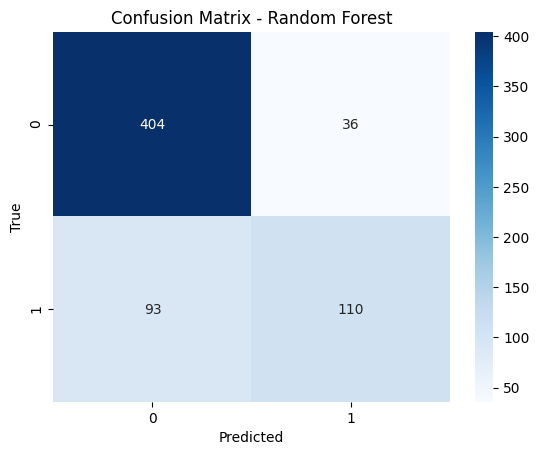

In [24]:
cm = confusion_matrix(y_test, test_results['predicted_plan'])
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix - Random Forest')
plt.show()

The confusion matrix for the Random Forest model shows the following results:

404 Smart users and 110 Ultra users were correctly classified.
The model misclassified 93 Smart users as Ultra and 36 Ultra users as Smart.

Most predictions lie along the diagonal, which confirms that the model performs well and makes consistent, logical predictions.
The small number of misclassifications mainly involves users whose behavior is close to the boundary between the two plans, which is expected in this type of classification problem.

Overall, the sanity check confirms that the model is working properly and that its predictions make sense given the nature of the data.

This project focused on building a machine learning model for Megaline to recommend the most suitable mobile plan for its customers based on their monthly behavior.
The process included data exploration, model training, hyperparameter tuning, and evaluation using a separate test set.

The dataset contained information about calls, messages, and internet usage for each user. After confirming that the data was clean and properly structured, it was divided into training, validation, and test sets (60/20/20).

The sanity check confirmed that the model’s predictions were logical — users with higher data and call usage were correctly classified as Ultra plan subscribers, while users with lower activity were predicted as Smart plan users.

Overall, this project demonstrated the importance of model comparison and parameter tuning to achieve reliable predictions.
The final Random Forest model can be considered a robust and practical tool to support Megaline’s marketing team in recommending appropriate plans for their customers.

End of project

<div class="alert alert-block alert-success">
<b>Reviewer's comment v1:</b> </a>

Sanity check looking great! Showcasing a confusion matrix is a good way of reviewing your model's performance!
    
</div>

<div class="alert alert-block alert-warning">
<b>Reviewer's comment v1:</b> </a>

You should update your conclusions once you address the previous comments!

</div>

<div class="alert alert-block alert-info">
<b></b> </a>
I believe that the confusion matrix and the conclusions do not need to be changed.
Although I tested both the DecisionTreeClassifier and the RandomForestClassifier, I chose the Random Forest model to create the confusion matrix and to write the conclusions.
As you can see, I only computed the test accuracy for these two models, but all the interpretations and final conclusions were based on the model that achieved the best performance — the Random Forest.</div>